In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student_engagement_data_10000.csv")
df

,Student ID,Session ID,Date,EEG Data (PSD Features),Engagement Level,Attention Level,Internet Connectivity,Adaptivity Level,Learning Mode Prediction,Performance Metrics
0,1,183,2025-01-20,"[0.02336871035675725, 0.14892576656473, 0.4845...",High,High,High (Mobile/Wi-Fi),Moderate,Visual Learner,84
1,2,121,2025-01-20,"[0.3587673311624021, 0.8537981137219391, 0.420...",Low,High,Moderate (Wi-Fi),High,Auditory Learner,82
2,3,169,2025-01-10,"[0.7420744093003028, 0.9072353407615483, 0.122...",Moderate,High,Low (Mobile),Low,Auditory Learner,83
3,4,132,2025-01-20,"[0.5596059164442914, 0.4645215049524961, 0.062...",High,Moderate,Low (Mobile),Moderate,Visual Learner,66
4,5,190,2025-01-18,"[0.15041646487754368, 0.7331633184349893, 0.86...",High,High,High (Mobile/Wi-Fi),Moderate,Auditory Learner,93
...,...,...,...,...,...,...,...,...,...,...
9995,9996,136,2025-01-22,"[0.509843622253183, 0.06323592642360798, 0.009...",High,High,High (Mobile/Wi-Fi),Low,Auditory Learner,63
9996,9997,123,2025-01-28,"[0.7755554254921619, 0.7736343505972849, 0.406...",High,High,Moderate (Wi-Fi),High,Auditory Learner,79
9997,9998,162,2025-01-14,"[0.1584875069299465, 0.13541608777847447, 0.09...",Low,Low,Low (Mobile),High,Visual Learner,66
9998,9999,154,2025-01-15,"[0.930660706451791, 0.9327867175259232, 0.2261...",Moderate,Moderate,Low (Mobile),Moderate,Auditory Learner,86


In [3]:
df.isnull().sum()

Student ID                  0
Session ID                  0
Date                        0
EEG Data (PSD Features)     0
Engagement Level            0
Attention Level             0
Internet Connectivity       0
Adaptivity Level            0
Learning Mode Prediction    0
Performance Metrics         0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Student ID                10000 non-null  int64 
 1   Session ID                10000 non-null  int64 
 2   Date                      10000 non-null  object
 3   EEG Data (PSD Features)   10000 non-null  object
 4   Engagement Level          10000 non-null  object
 5   Attention Level           10000 non-null  object
 6   Internet Connectivity     10000 non-null  object
 7   Adaptivity Level          10000 non-null  object
 8   Learning Mode Prediction  10000 non-null  object
 9   Performance Metrics       10000 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 781.4+ KB


In [5]:
new_df= df.iloc[:,4:]
new_df["Engagement Level"].unique()

array(['High', 'Low', 'Moderate'], dtype=object)

In [6]:
data = new_df.replace({"High":1,"Moderate":2,"Low":3})
data

C:\Users\HP\AppData\Local\Temp\ipykernel_9044\4008184881.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = new_df.replace({"High":1,"Moderate":2,"Low":3})


,Engagement Level,Attention Level,Internet Connectivity,Adaptivity Level,Learning Mode Prediction,Performance Metrics
0,1,1,High (Mobile/Wi-Fi),2,Visual Learner,84
1,3,1,Moderate (Wi-Fi),1,Auditory Learner,82
2,2,1,Low (Mobile),3,Auditory Learner,83
3,1,2,Low (Mobile),2,Visual Learner,66
4,1,1,High (Mobile/Wi-Fi),2,Auditory Learner,93
...,...,...,...,...,...,...
9995,1,1,High (Mobile/Wi-Fi),3,Auditory Learner,63
9996,1,1,Moderate (Wi-Fi),1,Auditory Learner,79
9997,3,3,Low (Mobile),1,Visual Learner,66
9998,2,2,Low (Mobile),2,Auditory Learner,86


In [7]:
data["Internet Connectivity"].unique()
data["Internet Connectivity"]= data["Internet Connectivity"].replace({"High (Mobile/Wi-Fi)": 1, "Moderate (Wi-Fi)":2, "Low (Mobile)":3 })

C:\Users\HP\AppData\Local\Temp\ipykernel_9044\2541969393.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Internet Connectivity"]= data["Internet Connectivity"].replace({"High (Mobile/Wi-Fi)": 1, "Moderate (Wi-Fi)":2, "Low (Mobile)":3 })


In [8]:
data = data.iloc[:,:4]
data["Adaptivity Level"].value_counts()

Adaptivity Level
2    3360
3    3331
1    3309
Name: count, dtype: int64

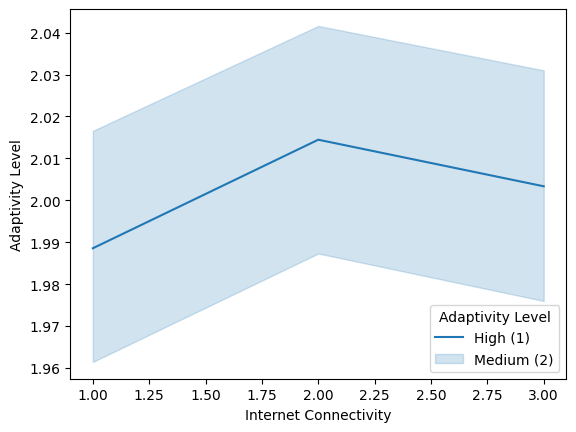

In [9]:
sns.lineplot(data, x = "Internet Connectivity", y = "Adaptivity Level"  )
plt.legend(title = "Adaptivity Level",labels=["High (1)", "Medium (2)", "Low (3)"])

<Axes: xlabel='Internet Connectivity', ylabel='Engagement Level'>

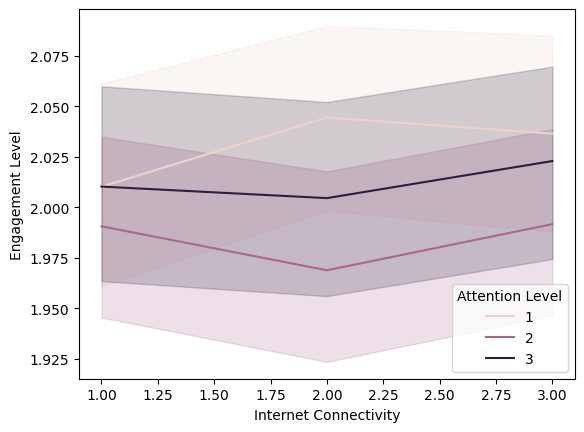

In [10]:
sns.lineplot(data, x= "Internet Connectivity",y ="Engagement Level", hue = "Attention Level")

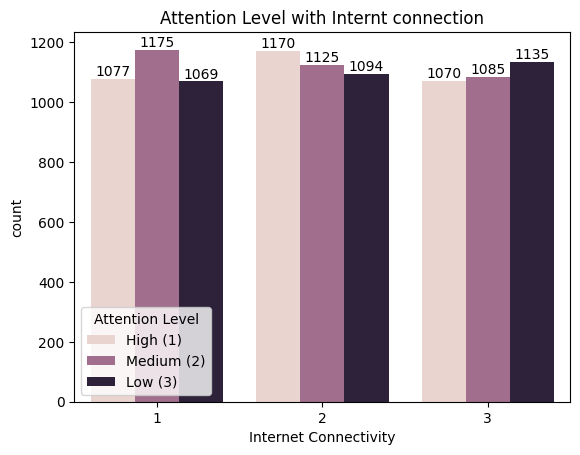

In [19]:
plot =sns.countplot(data = data , x= "Internet Connectivity", hue = "Attention Level")
plt.title("Attention Level with Internt connection")
plt.legend(
    title="Attention Level", 
    labels=["High (1)", "Medium (2)", "Low (3)"]
)
for container in plot.containers:
    plot.bar_label(container)

<Axes: xlabel='Adaptivity Level', ylabel='Engagement Level'>

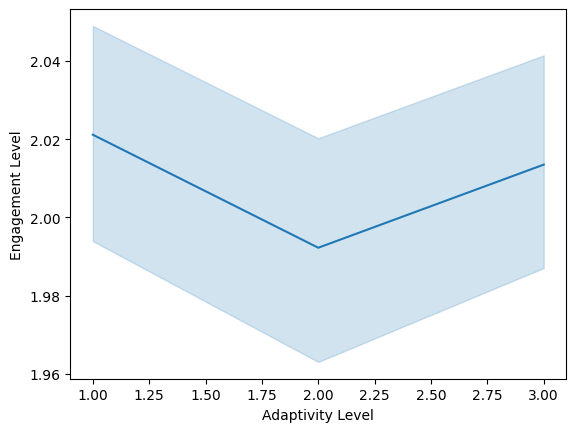

In [19]:
sns.lineplot(data = data, x = "Adaptivity Level", y = "Engagement Level")

In [14]:
data

,Engagement Level,Attention Level,Internet Connectivity,Adaptivity Level
0,1,1,1,2
1,3,1,2,1
2,2,1,3,3
3,1,2,3,2
4,1,1,1,2
...,...,...,...,...
9995,1,1,1,3
9996,1,1,2,1
9997,3,3,3,1
9998,2,2,3,2
